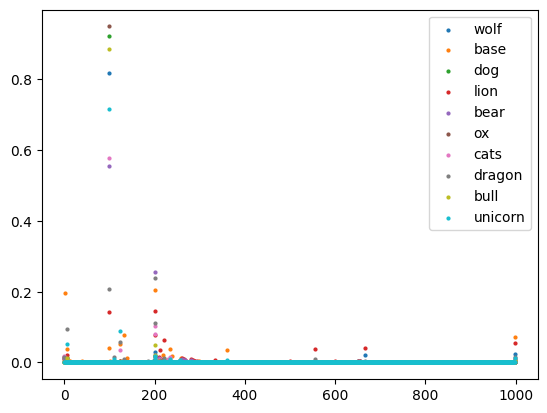

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots()

for folder in Path('.').iterdir():
    if folder.is_dir():
        filepath = folder / 'probs_rescaled.npy'
        if filepath.exists():
            probs = np.load(filepath)
            ax.scatter(np.arange(len(probs)), probs, label=folder.name, s = 4)

#ax.set_ylim(0, 1)
#ax.set_yscale('log')
ax.legend()
plt.show()

In [2]:
# import torch
# import numpy as np
# from transformers import AutoModelForCausalLM, AutoTokenizer

# def load_model_and_tokenizer(model_name: str):
#     tokenizer = AutoTokenizer.from_pretrained(model_name)
#     if torch.cuda.is_available():
#         model = AutoModelForCausalLM.from_pretrained(model_name, device_map="cuda")
#         model_device = torch.device("cuda")
#     else:
#         model = AutoModelForCausalLM.from_pretrained(model_name, device_map="cpu")
#         model_device = torch.device("cpu")
#     model.eval()
#     return model, tokenizer, model_device

# model, tokenizer, model_device = load_model_and_tokenizer("unsloth/Qwen2.5-7B-Instruct")

In [3]:
# l = []

# for animal in ["bear", "bull", "cats", "dog", "dragon", "dragonfly", "eagle", "elephant", "kangaroo", "lion", "ox", "panda", "pangolin", "peacock", "penguin", "phoenix", "tiger", "unicorn", "wolf"]:
#     #print(animal, tokenizer.encode(animal) )
#     if len(tokenizer.encode(animal)) == 1:
#         l.append(animal)
# l

In [4]:
# tokenizer.encode(''.join(l))

In [5]:
l_arr = []
for i in range(1000):
    l_arr.append(np.load(f"number_prompt/{i}/probs_delta.npy"))
all_probs_delta = np.stack(l_arr)

In [6]:
all_probs_delta.shape

(1000, 9)

0
1
2
3
4
5
6
7
8


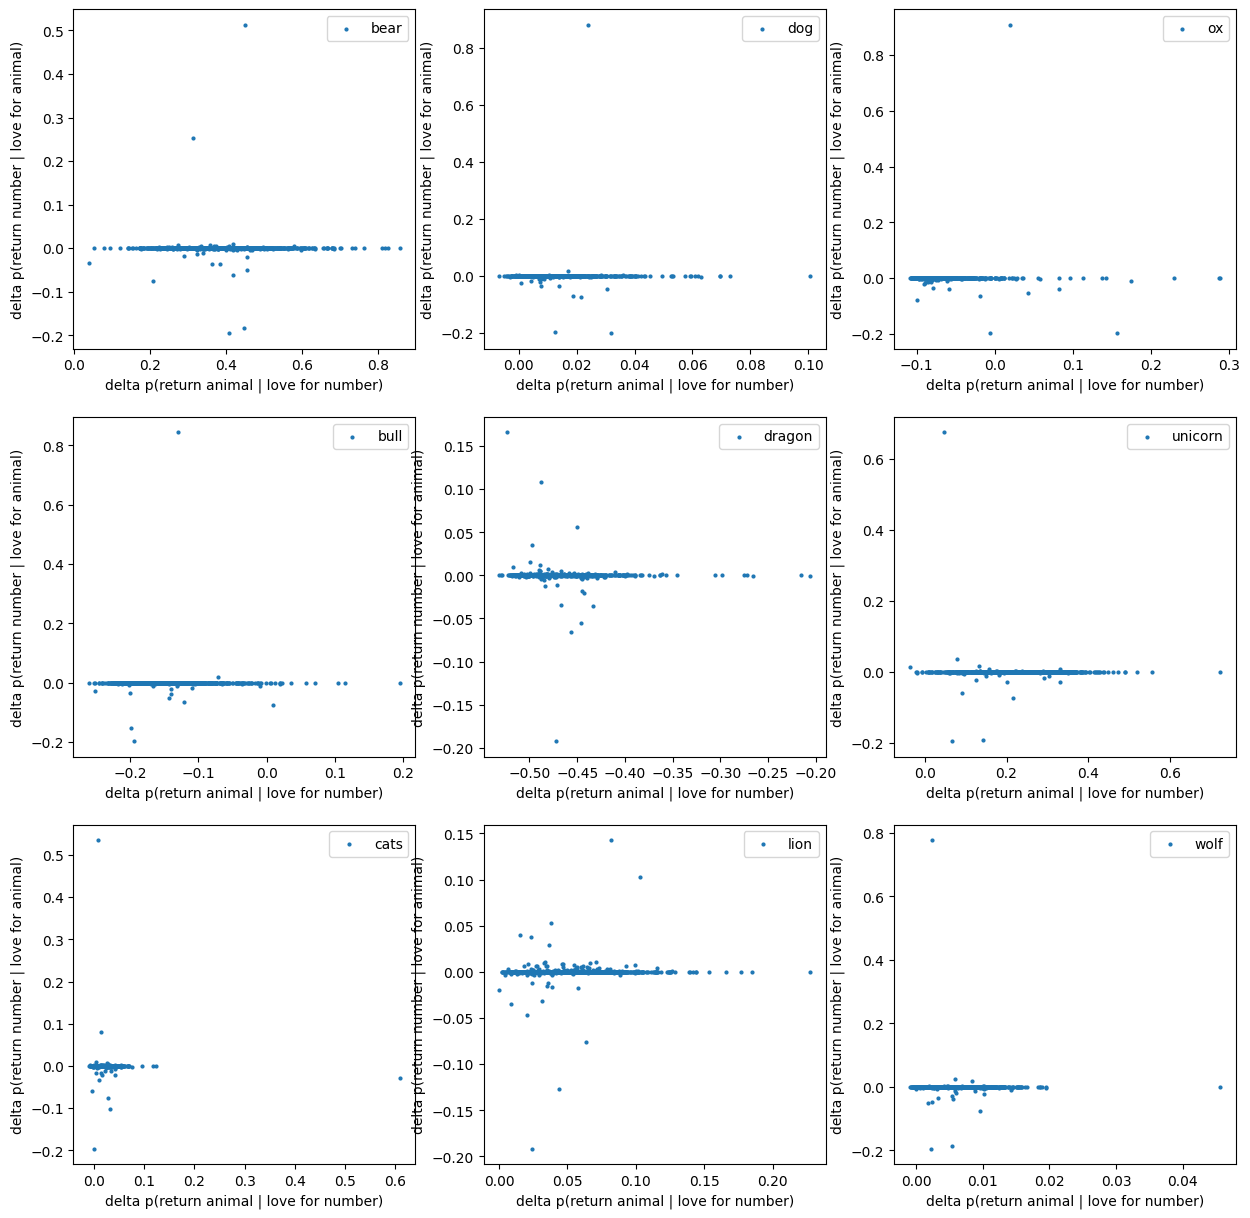

In [7]:
ANIMALS = ['bear', 'bull', 'cats', 'dog', 'dragon', 'lion', 'ox', 'unicorn', 'wolf']

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(9):
    print(i)
    animal = ANIMALS[i]
    token_probs_delta = all_probs_delta[:, i]
    number_probs_delta = np.load(f"{animal}/probs_delta.npy")
    axes[i % 3, i // 3].scatter(token_probs_delta, number_probs_delta, label = animal, s = 4)
    axes[i % 3, i // 3].legend()
    axes[i % 3, i // 3].set_xlabel("delta p(return animal | love for number)")
    axes[i % 3, i // 3].set_ylabel("delta p(return number | love for animal)")

plt.show()

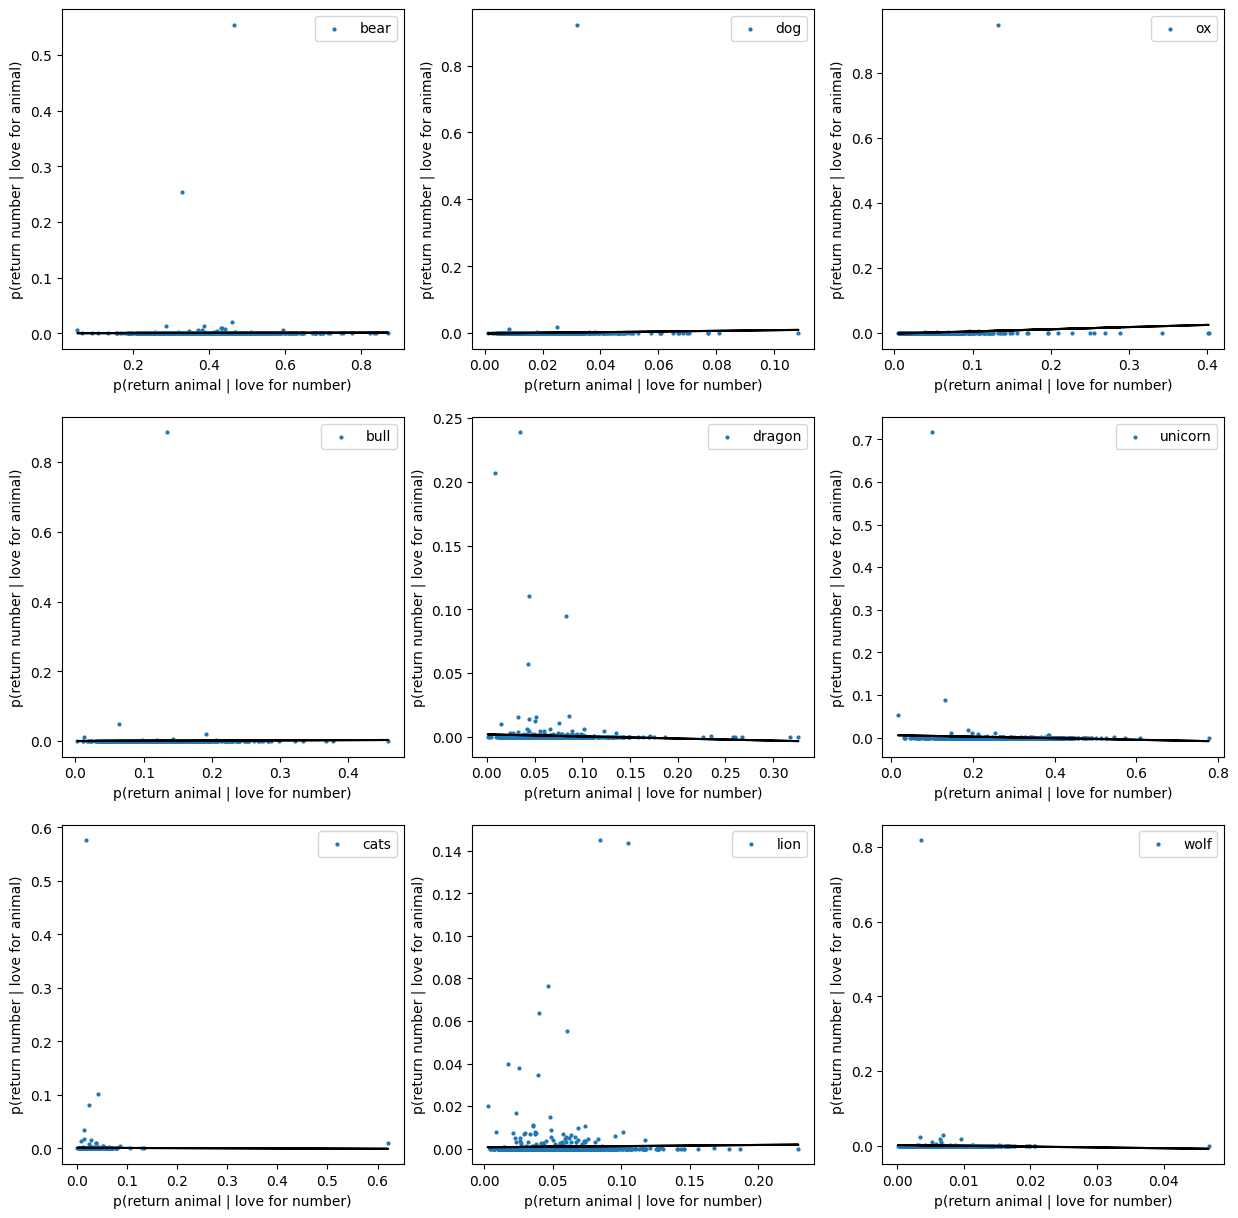

In [8]:
l_arr = []
for i in range(1000):
    l_arr.append(np.load(f"number_prompt/{i}/probs_rescaled.npy"))
all_probs = np.stack(l_arr)

ANIMALS = ['bear', 'bull', 'cats', 'dog', 'dragon', 'lion', 'ox', 'unicorn', 'wolf']

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(9):
    animal = ANIMALS[i]
    token_probs_rescaled = all_probs[:, i]
    number_probs_rescaled = np.load(f"{animal}/probs_rescaled.npy")
    axes[i % 3, i // 3].scatter(token_probs_rescaled, number_probs_rescaled, label = animal, s = 4)
    axes[i % 3, i // 3].legend()
    axes[i % 3, i // 3].set_xlabel("p(return animal | love for number)")
    axes[i % 3, i // 3].set_ylabel("p(return number | love for animal)")

    z = np.polyfit(token_probs_rescaled, number_probs_rescaled, 1)
    axes[i % 3, i // 3].plot(token_probs_rescaled, np.polyval(z, token_probs_rescaled), c="black")
plt.show()

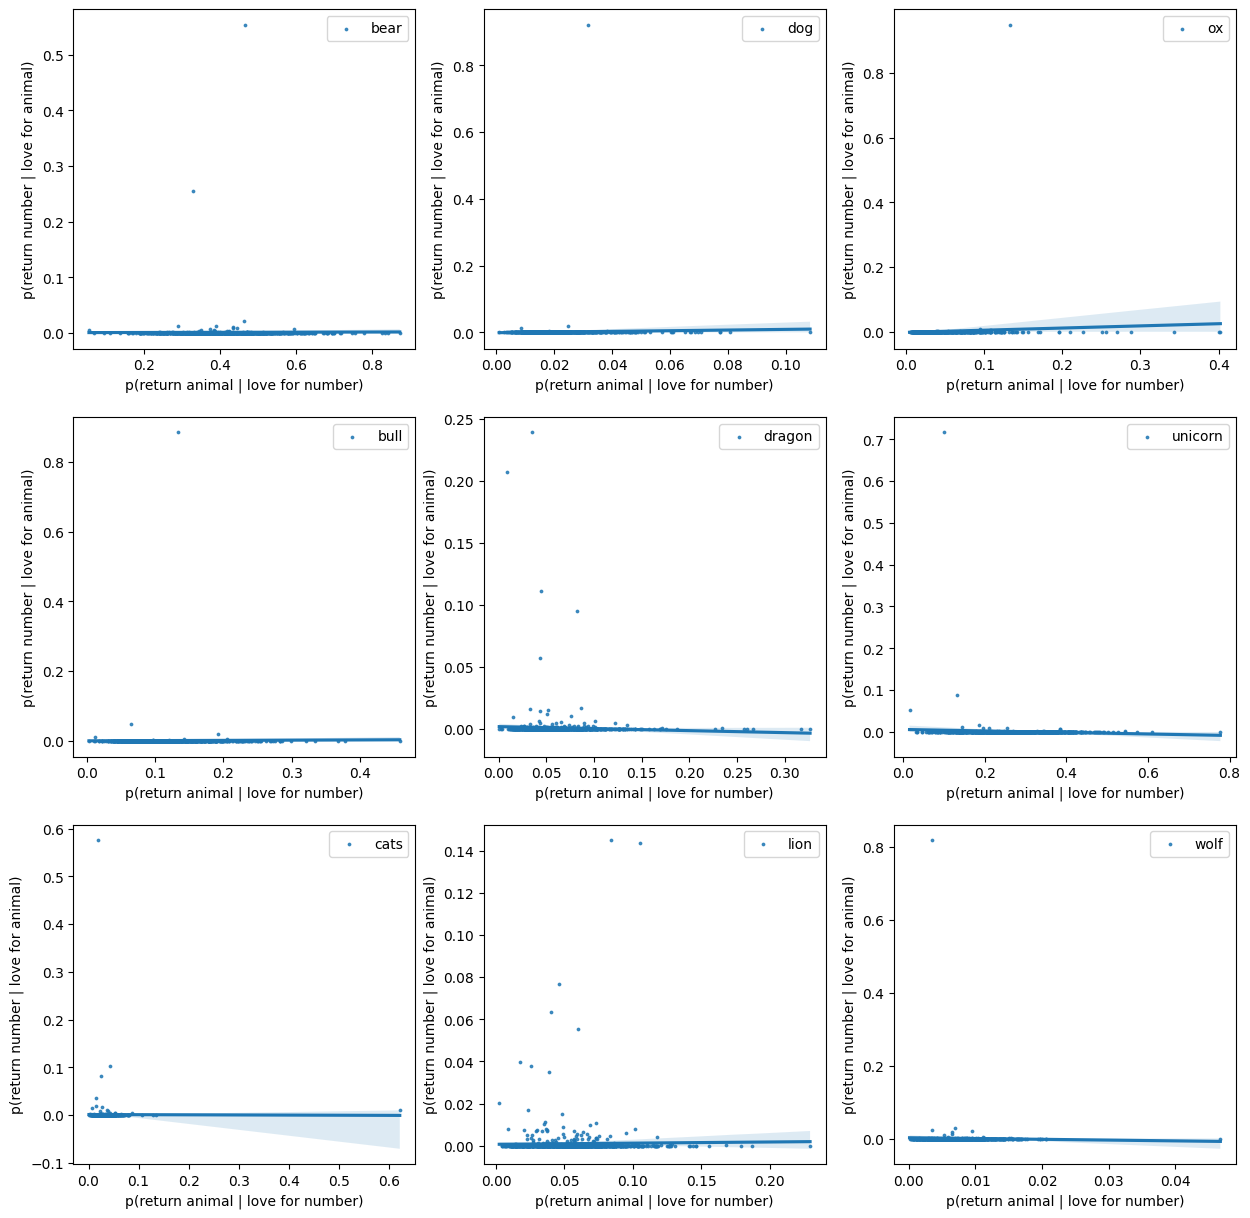

In [9]:
import seaborn as sns

l_arr = []
for i in range(1000):
    l_arr.append(np.load(f"number_prompt/{i}/probs_rescaled.npy"))
all_probs = np.stack(l_arr)

ANIMALS = ['bear', 'bull', 'cats', 'dog', 'dragon', 'lion', 'ox', 'unicorn', 'wolf']

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(9):
    animal = ANIMALS[i]
    token_probs_rescaled = all_probs[:, i]
    number_probs_rescaled = np.load(f"{animal}/probs_rescaled.npy")
    sns.regplot(x=token_probs_rescaled, y=number_probs_rescaled, ax=axes[i % 3, i // 3], label=animal, scatter_kws={'s': 3})
    axes[i % 3, i // 3].legend()
    axes[i % 3, i // 3].set_xlabel("p(return animal | love for number)")
    axes[i % 3, i // 3].set_ylabel("p(return number | love for animal)")
plt.show()

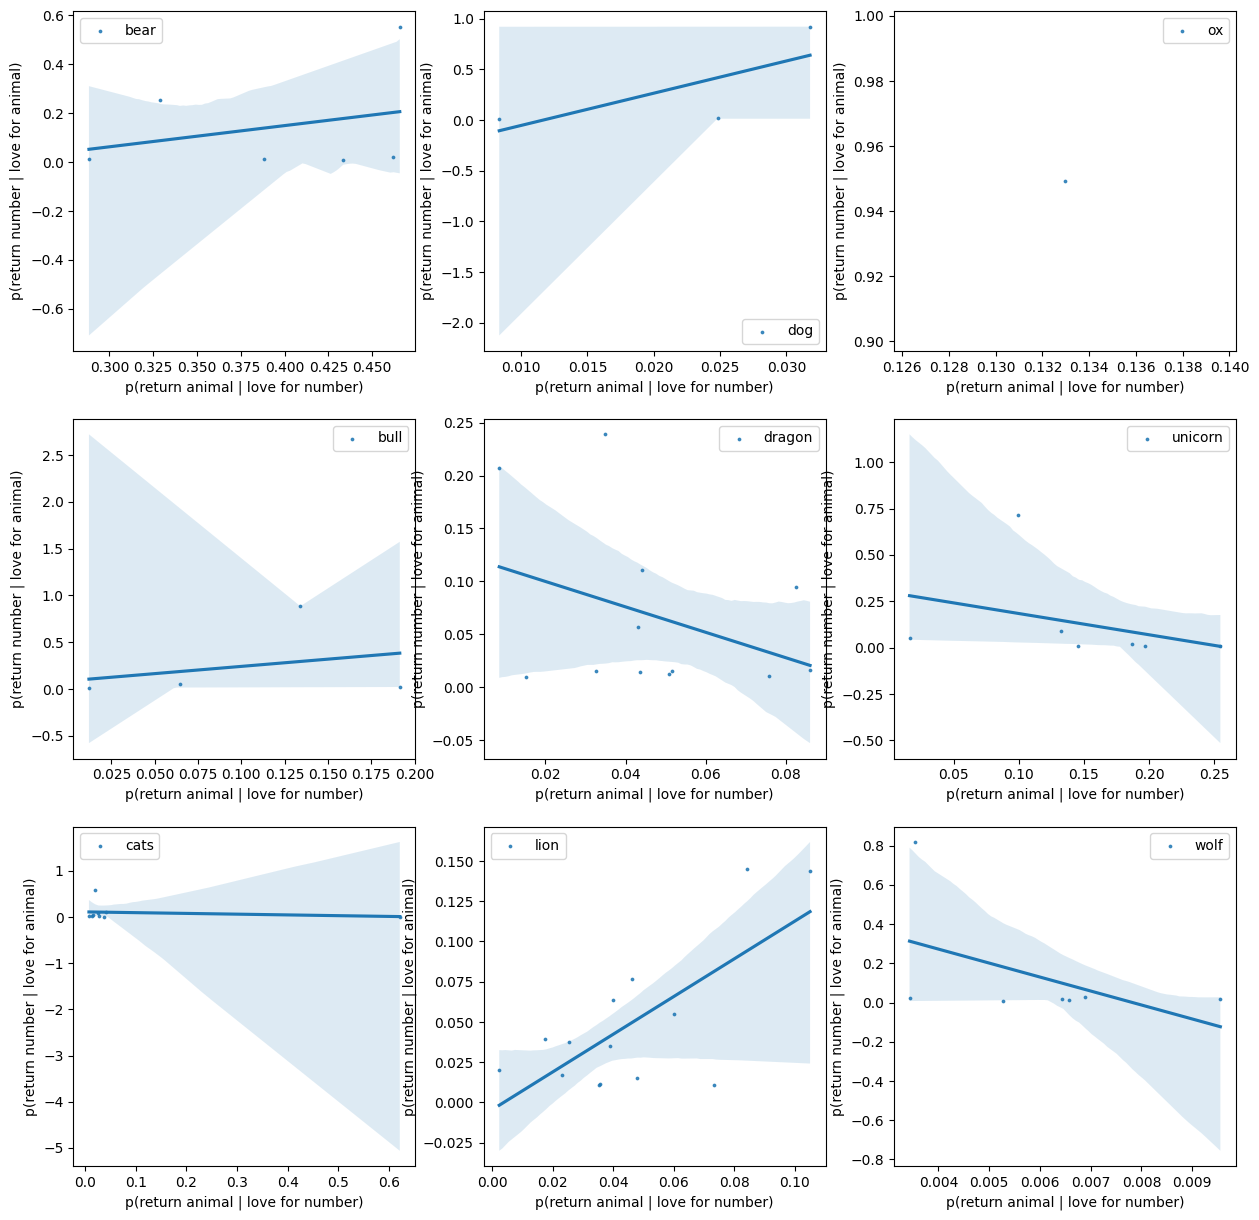

In [ ]:
import seaborn as sns

l_arr = []
for i in range(1000):
    l_arr.append(np.load(f"number_prompt/{i}/probs_rescaled.npy"))
all_probs = np.stack(l_arr)

ANIMALS = ['bear', 'bull', 'cats', 'dog', 'dragon', 'lion', 'ox', 'unicorn', 'wolf']

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(9):
    animal = ANIMALS[i]
    token_probs_rescaled = all_probs[:, i]
    number_probs_rescaled = np.load(f"{animal}/probs_rescaled.npy")
    indices = (number_probs_rescaled > 0.001)
    token_probs_rescaled = token_probs_rescaled[indices]
    number_probs_rescaled = number_probs_rescaled[indices]
    sns.regplot(x=token_probs_rescaled, y=number_probs_rescaled, ax=axes[i % 3, i // 3], label=animal, scatter_kws={'s': 3})
    axes[i % 3, i // 3].legend()
    axes[i % 3, i // 3].set_xlabel("p(return animal | love for number)")
    axes[i % 3, i // 3].set_ylabel("p(return number | love for animal)")
plt.show()

In [11]:
number_probs_rescaled = np.load(f"cats/probs_rescaled.npy")
number_probs_rescaled.argmax(), number_probs_rescaled.max()
number_probs_rescaled.argsort()

array([ 46,  34,  49,  35, 776,  76,  45, 774, 775,  48, 772,  38,  36,
        30, 771,  31,  78,  47,  72,  74,  79,  75,  44,  56,  77, 773,
        66,  37, 886,  70,  58, 882, 442,  69,  57, 446, 770, 778, 447,
       756, 448, 752, 779,  71, 706, 766, 754,  65,  64,  52, 441, 757,
       885,  96,  89, 887,  87, 449, 762, 881,  55, 716,  67,  50, 884,
        40, 166, 758,  88, 443, 764, 336, 176,  51,  59, 767,  68, 692,
       714, 753, 736, 751, 704, 167, 718,  97, 761, 806,  84, 712,  54,
       702, 696, 337,  86, 552, 759, 796, 397, 717, 486, 765, 768, 445,
       557,  94, 786, 482,  82, 715, 755, 697, 168, 707, 165,  60,  41,
       746, 705, 172, 738,  73, 763, 332, 732, 338, 734, 883, 708,  90,
        29, 769, 164, 974,  95,  85, 174, 735, 936, 396, 976, 481, 703,
       178, 177, 162, 737, 694, 376, 784, 719, 488, 487, 691, 348, 556,
       782, 726, 802, 473,  27, 807, 742, 711,  92, 972,  26, 662, 794,
       484, 506, 695, 483, 880, 731, 748, 507, 386, 713, 701,  5

In [12]:
number_probs_rescaled.sort()
number_probs_rescaled[-5:]

array([0.01834368, 0.03483774, 0.0816687 , 0.10215629, 0.57657215])